# Practical 4: Dimensionality Reduction — PCA vs. Autoencoders
## Deep Learning Lab | BTech Semester 4

### Objective
Compare traditional linear dimensionality reduction (PCA) with neural dimensionality reduction (Autoencoders).


In [28]:
#importing libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.decomposition import PCA
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)
print('Libraries loaded!')

Libraries loaded!


## Step 2: Load and Prepare MNIST
MNIST: 70,000 handwritten digit images, 28x28 pixels, 10 classes (0-9).
We reduce each image from 784 dimensions down to just 2 for 2D visualization.

Train: (60000, 784), Test: (10000, 784)


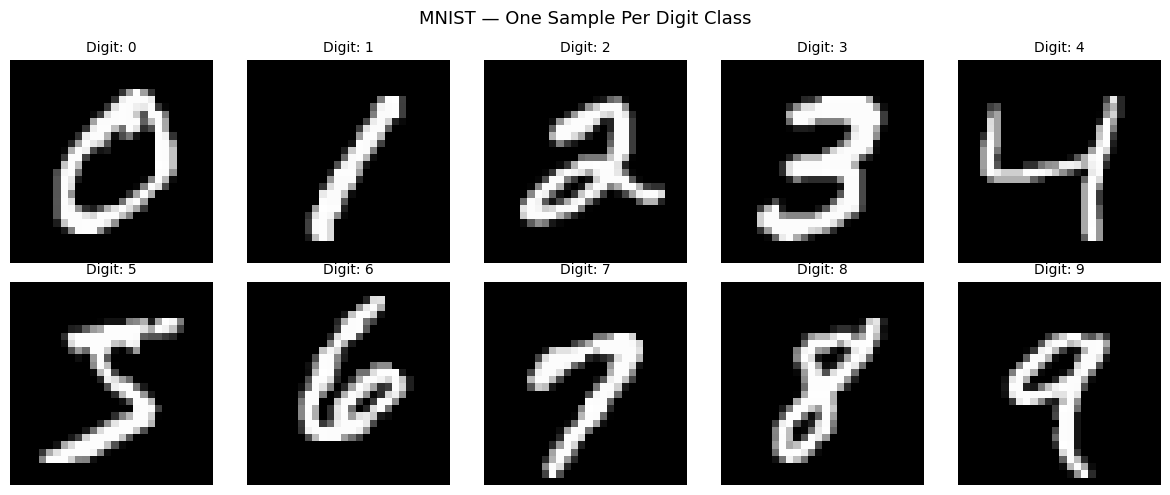

In [29]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

# Flatten and normalize pixels to [0, 1]
X_train_flat = X_train.reshape(-1, 784).astype('float32') / 255.0
X_test_flat  = X_test.reshape(-1, 784).astype('float32')  / 255.0

print(f'Train: {X_train_flat.shape}, Test: {X_test_flat.shape}')

# Use a subset for faster visualization
N = 20000
X_sub = X_train_flat[:N]
y_sub = y_train[:N]

# Visualize sample digits — one per class
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for digit, ax in enumerate(axes.flatten()):
    idx = np.where(y_train == digit)[0][0]
    ax.imshow(X_train[idx], cmap='gray')
    ax.set_title(f'Digit: {digit}', fontsize=10)
    ax.axis('off')
plt.suptitle('MNIST — One Sample Per Digit Class', fontsize=13)
plt.tight_layout()
plt.show()

## Step 3: PCA — Principal Component Analysis

PCA finds the directions (principal components) of maximum variance in the data.
It is a LINEAR method — can only capture linear relationships between features.

Steps:
1. Center the data (subtract mean)
2. Compute covariance matrix
3. Compute eigenvectors (principal components) and eigenvalues
4. Project data onto top-K eigenvectors

Reducing 784 dimensions to 2 necessarily loses information!

In [30]:
# Fit PCA and reduce to 2 dimensions for visualization
pca = PCA(n_components=80, random_state=42)
X_pca = pca.fit_transform(X_sub)  # Shape: (N, 2)

print(f'Original shape: {X_sub.shape}')
print(f'PCA reduced shape: {X_pca.shape}')
print(f'Variance explained by PC1: {pca.explained_variance_ratio_[0]*100:.2f}%')
print(f'Variance explained by PC2: {pca.explained_variance_ratio_[1]*100:.2f}%')
print(f'Total variance explained: {sum(pca.explained_variance_ratio_)*100:.2f}%')
print(f'Information lost by using only 2 components: {(1-sum(pca.explained_variance_ratio_))*100:.1f}%')

Original shape: (20000, 784)
PCA reduced shape: (20000, 80)
Variance explained by PC1: 9.86%
Variance explained by PC2: 7.09%
Total variance explained: 89.21%
Information lost by using only 2 components: 10.8%


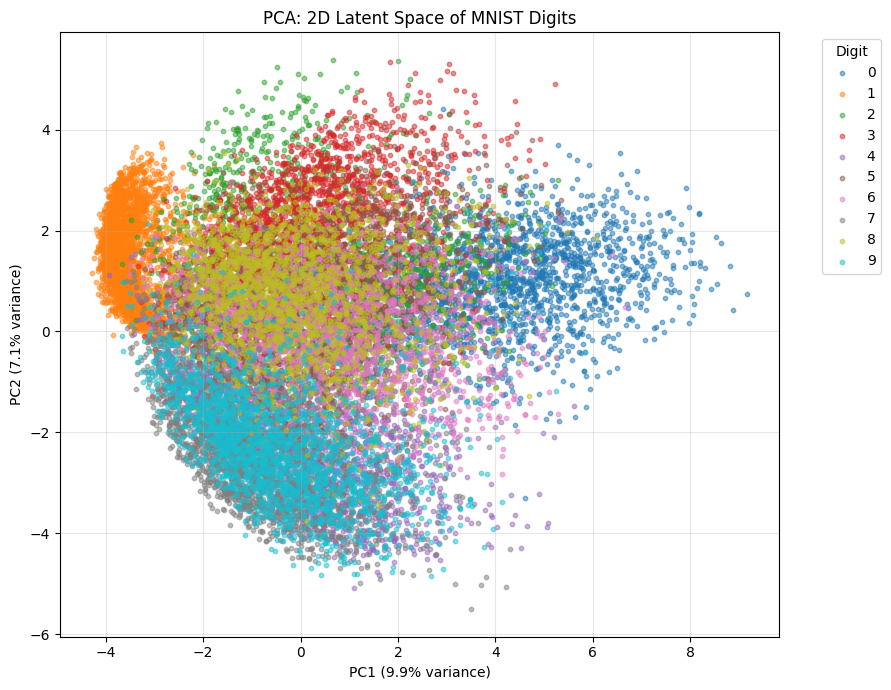

In [31]:
# Visualize PCA 2D latent space — color-coded by digit
colors = cm.tab10(np.linspace(0, 1, 10))
plt.figure(figsize=(9, 7))
for digit in range(10):
    mask = y_sub == digit
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=[colors[digit]], label=str(digit), alpha=0.5, s=10)
plt.legend(title='Digit', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('PCA: 2D Latent Space of MNIST Digits', fontsize=12)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 4: Build the Autoencoder

An Autoencoder is a neural network trained to:
- **Encode**: compress input (784 dims) to a small bottleneck (2 dims)
- **Decode**: reconstruct the original input from the bottleneck

Architecture:
```
Input(784) -> Dense(256) -> Dense(64) -> Bottleneck(2) -> Dense(64) -> Dense(256) -> Output(784)
```

The bottleneck forces the network to learn a compact, meaningful representation.
Unlike PCA, autoencoders can capture NON-LINEAR relationships between features.

In [32]:
LATENT_DIM = 2  # Same bottleneck size as PCA for fair comparison

# --- ENCODER: compresses 784 -> 2 ---
encoder_input = keras.Input(shape=(784,), name='encoder_input')
x = layers.Dense(256, activation='relu', name='enc_1')(encoder_input)
x = layers.Dense(64,  activation='relu', name='enc_2')(x)
latent = layers.Dense(LATENT_DIM, activation='linear', name='bottleneck')(x)
encoder = keras.Model(encoder_input, latent, name='Encoder')

# --- DECODER: reconstructs 2 -> 784 ---
decoder_input = keras.Input(shape=(LATENT_DIM,), name='decoder_input')
x = layers.Dense(64,  activation='relu', name='dec_1')(decoder_input)
x = layers.Dense(256, activation='relu', name='dec_2')(x)
output = layers.Dense(784, activation='sigmoid', name='decoder_output')(x)  # Sigmoid for [0,1] pixels
decoder = keras.Model(decoder_input, output, name='Decoder')

# --- FULL AUTOENCODER ---
ae_input = keras.Input(shape=(784,))
ae_output = decoder(encoder(ae_input))
autoencoder = keras.Model(ae_input, ae_output, name='Autoencoder')

# MSE loss: measures pixel-by-pixel reconstruction error
autoencoder.compile(optimizer='adam', loss='mse')
print('Autoencoder built!')
autoencoder.summary()

Autoencoder built!


Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder (Functional)            │ (None, 2)              │       217,538 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder (Functional)            │ (None, 784)            │       218,320 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 435,858 (1.66 MB)

 Trainable params: 435,858 (1.66 MB)

 Non-trainable params: 0 (0.00 B)

## Step 5: Train the Autoencoder
Key insight: Input = Target = X (unsupervised learning — no labels needed!)

Epoch 1/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0793 - val_loss: 0.0606
Epoch 2/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0572 - val_loss: 0.0548
Epoch 3/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0534 - val_loss: 0.0524
Epoch 4/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0505 - val_loss: 0.0498
Epoch 5/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0480 - val_loss: 0.0477
Epoch 6/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0462 - val_loss: 0.0461
Epoch 7/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0450 - val_loss: 0.0452
Epoch 8/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0441 - val_loss: 0.0445
Epoch 9/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0434 - val_loss: 0.0440
Epoch 10/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0428 - val_loss: 0.0436
Epoch 11/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0423 - val_loss: 0.0432
Epoch 12/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 

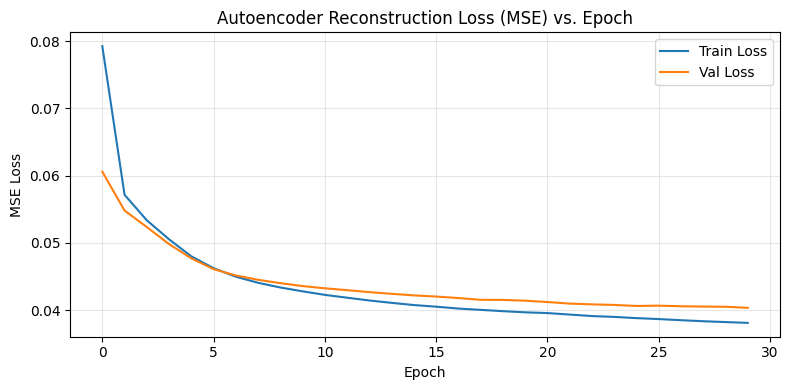

In [33]:
# Train: the autoencoder learns to minimize reconstruction error
history = autoencoder.fit(
    X_sub, X_sub,       # Input AND target are both X — self-supervised
    epochs=30,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Autoencoder Reconstruction Loss (MSE) vs. Epoch')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 6: Autoencoder Latent Space

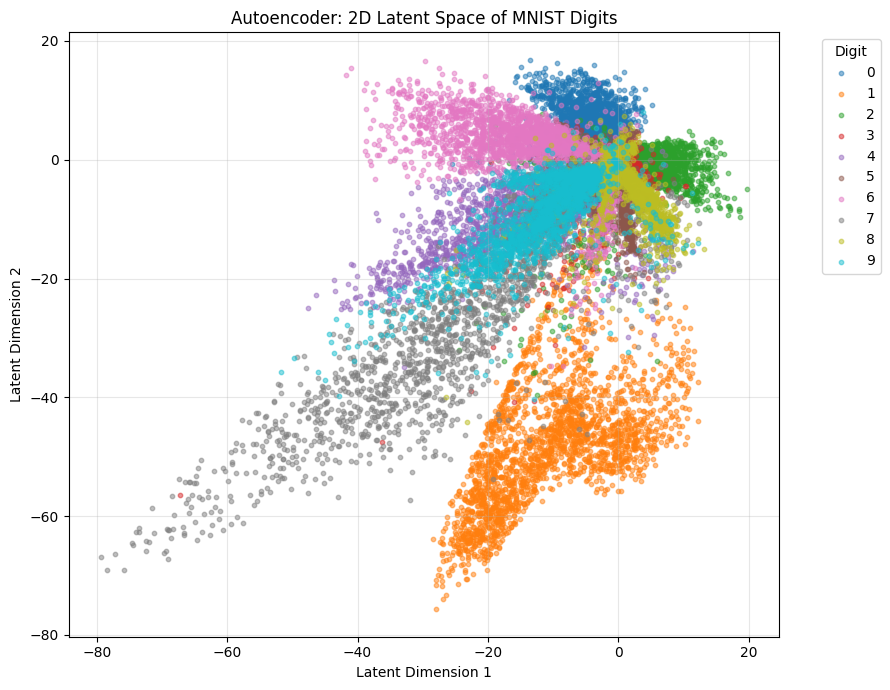

In [34]:
# Encode the data — get 2D latent representations
X_ae = encoder.predict(X_sub, verbose=0)

plt.figure(figsize=(9, 7))
for digit in range(10):
    mask = y_sub == digit
    plt.scatter(X_ae[mask, 0], X_ae[mask, 1],
                c=[colors[digit]], label=str(digit), alpha=0.5, s=10)
plt.legend(title='Digit', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Autoencoder: 2D Latent Space of MNIST Digits', fontsize=12)
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 7: Side-by-Side Comparison of Latent Spaces

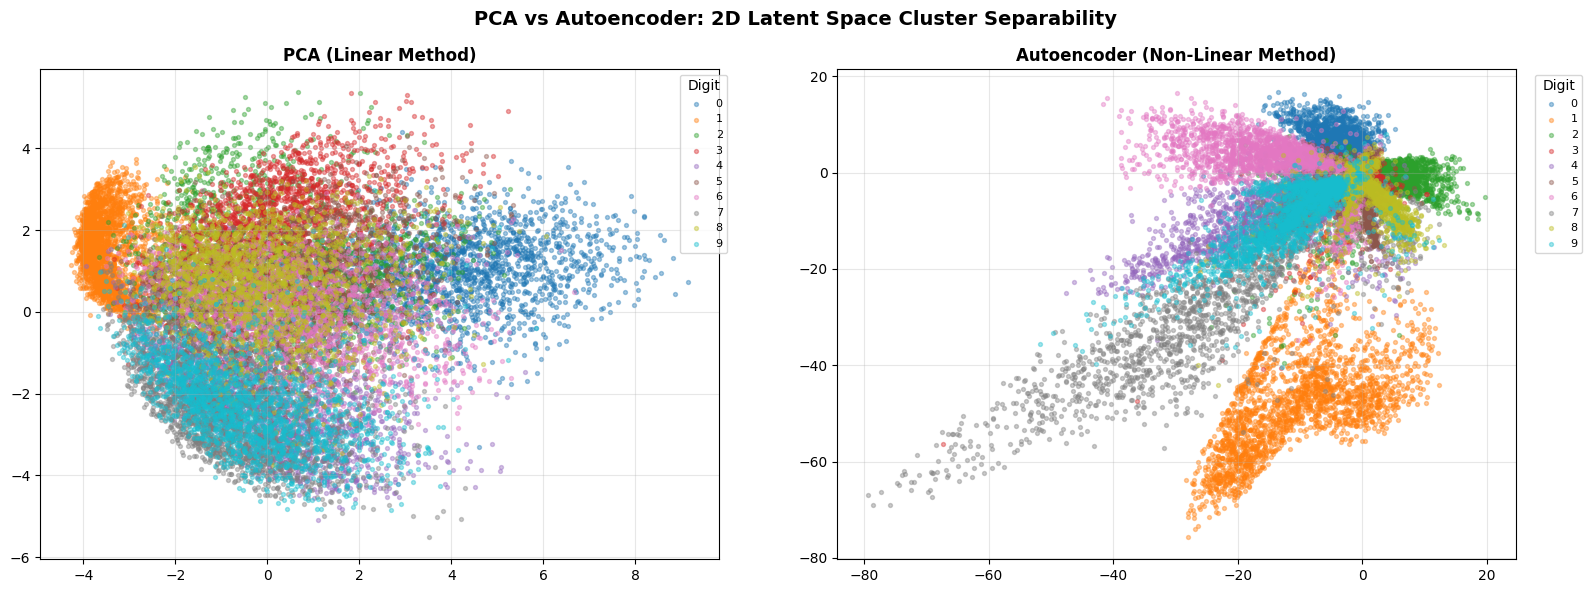

The Autoencoder generally shows better-separated digit clusters
because it can learn non-linear manifolds, unlike PCA which is restricted to linear projections.


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for digit in range(10):
    mask = y_sub == digit
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], c=[colors[digit]], label=str(digit), alpha=0.4, s=8)
    axes[1].scatter(X_ae[mask, 0], X_ae[mask, 1], c=[colors[digit]], label=str(digit), alpha=0.4, s=8)

for ax, title in zip(axes, ['PCA (Linear Method)', 'Autoencoder (Non-Linear Method)']):
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(title='Digit', bbox_to_anchor=(1.02, 1), fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('PCA vs Autoencoder: 2D Latent Space Cluster Separability', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('The Autoencoder generally shows better-separated digit clusters')
print('because it can learn non-linear manifolds, unlike PCA which is restricted to linear projections.')

## Step 8: Reconstruction Quality Comparison

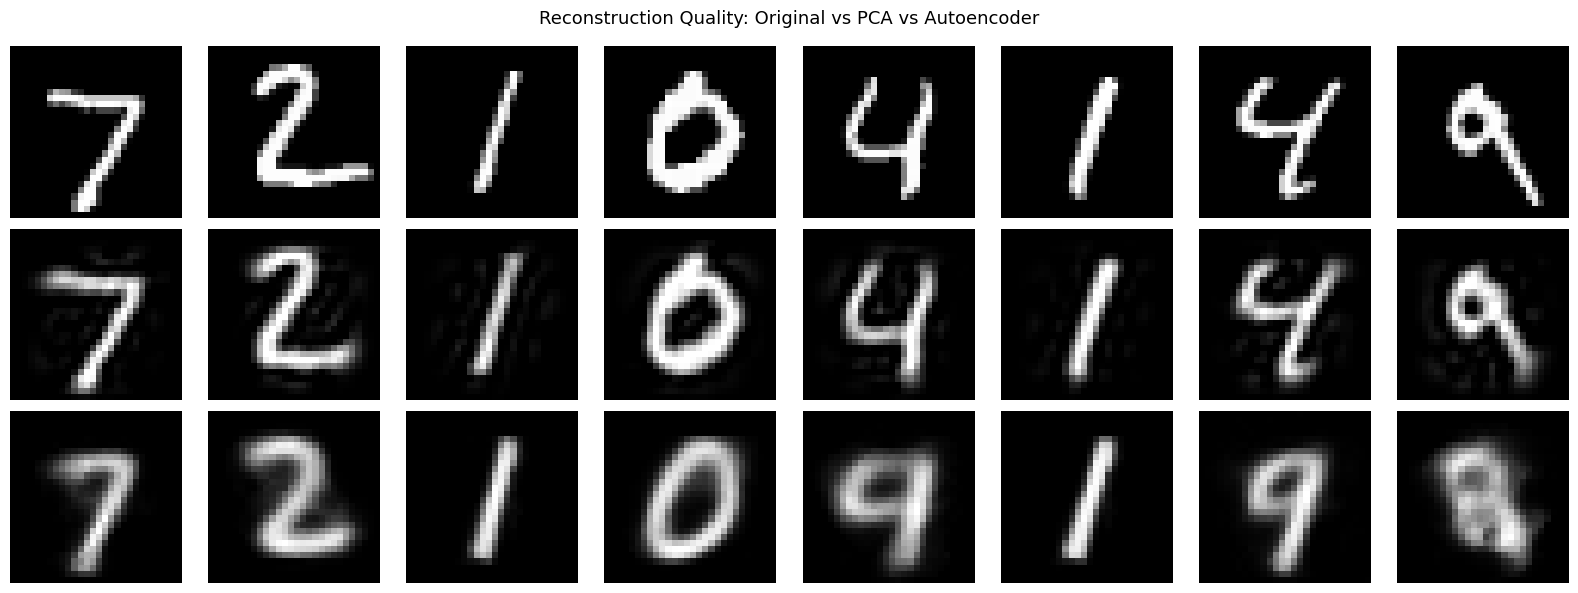

In [36]:
n_show = 8
sample = X_test_flat[:n_show]
ae_recon = autoencoder.predict(sample, verbose=0)

# PCA reconstruction via inverse_transform
pca_recon = np.clip(pca.inverse_transform(pca.transform(sample)), 0, 1)

fig, axes = plt.subplots(3, n_show, figsize=(16, 6))
row_labels = ['Original', 'PCA Recon.', 'AE Recon.']
for i in range(n_show):
    axes[0, i].imshow(sample[i].reshape(28, 28), cmap='gray')
    axes[1, i].imshow(pca_recon[i].reshape(28, 28), cmap='gray')
    axes[2, i].imshow(ae_recon[i].reshape(28, 28), cmap='gray')
    for r in range(3):
        axes[r, i].axis('off')
for r, lbl in enumerate(row_labels):
    axes[r, 0].set_ylabel(lbl, fontsize=11)
plt.suptitle('Reconstruction Quality: Original vs PCA vs Autoencoder', fontsize=13)
plt.tight_layout()
plt.show()

---
## Summary

| Aspect | PCA | Autoencoder |
|--------|-----|-------------|
| Method type | Linear | Non-linear |
| Training | Eigen-decomposition (fast) | Backprop (slower) |
| Reconstruction | Blurry | Sharper |
| Cluster separation | Partial overlap | Better separation |
| Interpretability | High (explained variance) | Low (black box) |

